In [6]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
import os
import sys
import gzip
from io import BytesIO
from astropy.io import fits
import matplotlib.pyplot as plt
import dropbox
import time
import glob
import warnings
import numpy as np
import pandas as pd
import re

from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from astropy.coordinates import SkyCoord
from astropy.nddata import Cutout2D
from astropy.table import Table
from astropy.wcs import FITSFixedWarning
from astropy import units as u
from scipy import ndimage
from skimage import restoration

import euclid_psf as ep
import clipping

#sys.path.insert(0, '/home/eaev/mer_psf/')
#from mer.psf.MerCatalogPsf import MerCatalogPsf as mpsf

In [8]:
jwst_cutouts, nisp_cutouts = clipping.process_all(
    'cosmos', 
    'NISP-Y',
    save_cat=True,
    save_clips=True,
    redo_cat=True,
    redo_clips=True,
    secret="/Users/shemmati/secrets/dropbox_token"  
)

Processing cosmos field with NISP-Y

[Step 1/5] Connecting to Dropbox...
✓ Connected to Dropbox

[Step 2/5] Listing files from Dropbox...
  Found 20 JWST files
  Found 32 NISP image files

[Step 3/5] Processing catalog...
  Applying selection criteria to catalog...
  ✓ 127162 galaxies passed selection criteria
  Matching galaxies to JWST files...


  Matching galaxies to NISP files...


  ✓ 39024 galaxies matched to both JWST and NISP images
  Saved catalog to ../catalog/matched_cat_cosmos_2_20251124.csv

[Step 4/5] Clipping images for 39024 galaxies...


  Clipping galaxies:  87%|████████▋ | 34058/39024 [35:28<05:10, 16.00gal/s]   


  ✓ Successfully clipped 34058 galaxy pairs

[Step 5/5] Arranging data...
  JWST cutouts shape: (34058, 205, 205)
  NISP cutouts shape: (34058, 41, 41)
  Saved cutouts to ../data/jwst_cosmos_205px_F115W_20251124.npy and ../data/euclid_NIR_cosmos_41px_Y_20251124.npy

Processing complete!


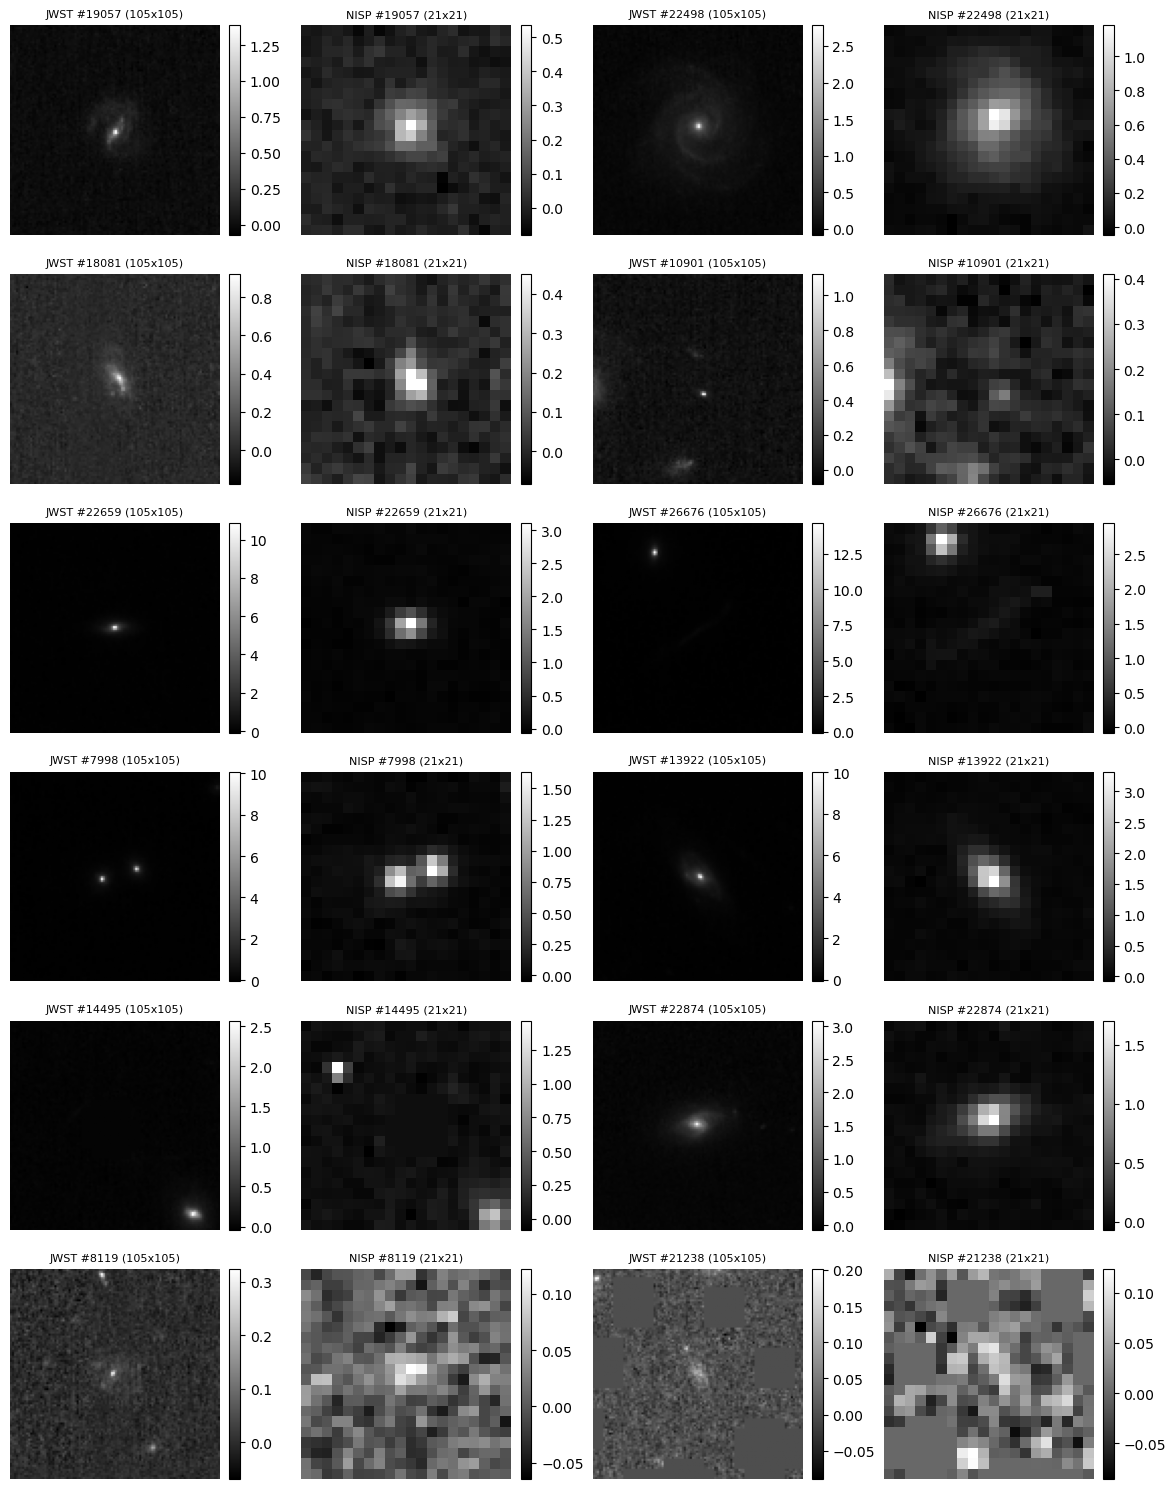

In [16]:
# Plotting images for verification purposes - random selection
n_rows = 6
n_samples = n_rows * 2  # 12 galaxy pairs

# Select random indices
np.random.seed(42)  # For reproducibility, remove if you want different random each time
random_indices = np.random.choice(len(jwst_cutouts), size=n_samples, replace=False)

# Crop sizes (half of original)
nisp_crop_size = 21  # Half of 41
jwst_crop_size = 105  # Half of 205

fig, axes = plt.subplots(n_rows, 4, figsize=(12, 2.5*n_rows))
for idx, i in enumerate(random_indices):
    clip_jwst = jwst_cutouts[i]
    clip_nisp = nisp_cutouts[i]
    
    # Crop to center region
    jwst_h, jwst_w = clip_jwst.shape
    nisp_h, nisp_w = clip_nisp.shape
    
    jwst_crop = clip_jwst[jwst_h//2 - jwst_crop_size//2:jwst_h//2 + jwst_crop_size//2,
                          jwst_w//2 - jwst_crop_size//2:jwst_w//2 + jwst_crop_size//2]
    nisp_crop = clip_nisp[nisp_h//2 - nisp_crop_size//2:nisp_h//2 + nisp_crop_size//2,
                          nisp_w//2 - nisp_crop_size//2:nisp_w//2 + nisp_crop_size//2]
    
    # Plot JWST
    im1 = axes.flatten()[idx*2].imshow(jwst_crop, origin='lower', cmap='gray')
    axes.flatten()[idx*2].set_title(f'JWST #{i} (105x105)', fontsize=8)
    axes.flatten()[idx*2].axis('off')
    plt.colorbar(im1, ax=axes.flatten()[idx*2], fraction=0.046, pad=0.04)
    
    # Plot NISP
    im2 = axes.flatten()[idx*2+1].imshow(nisp_crop, origin='lower', cmap='gray')
    axes.flatten()[idx*2+1].set_title(f'NISP #{i} (21x21)', fontsize=8)
    axes.flatten()[idx*2+1].axis('off')
    plt.colorbar(im2, ax=axes.flatten()[idx*2+1], fraction=0.046, pad=0.04)

plt.tight_layout()
# plt.savefig("../plots/euclid_nisp_matches.png", bbox_inches='tight')
plt.show()

In [17]:
import numpy as np
from astropy.stats import sigma_clipped_stats

# ------------------------------------------------------------
# 1) Estimate global normalization parameters
# ------------------------------------------------------------

def estimate_global_norm_params(cutouts, 
                                alpha=3.0, 
                                sample_frac=0.2, 
                                max_samples=50000):
    """
    Estimate global sigma_sky and global scale 's99' for a set of images.
    These params are then used for ALL images of that instrument.
    """
    # Randomly sample pixels from many cutouts
    n_cut = len(cutouts)
    n_use = int(n_cut * sample_frac)
    indices = np.random.choice(n_cut, size=n_use, replace=False)

    pixel_samples = []
    for idx in indices:
        img = cutouts[idx]

        # Background estimation
        mean, med, std = sigma_clipped_stats(img, sigma=3.0)
        img0 = img - med

        # Sky sigma from a masked distribution
        pixel_samples.append(img0.ravel())

    pixel_samples = np.concatenate(pixel_samples)

    # Global sky sigma (robust)
    _, _, sigma_sky = sigma_clipped_stats(pixel_samples, sigma=3.0)

    # Transform sample using (img - med)/sigma_sky
    X = pixel_samples / sigma_sky

    # Apply asinh stretch
    Y = np.arcsinh(X / alpha)

    # Global scale factor (99.7th percentile)
    s99 = np.percentile(np.abs(Y), 99.7)

    return {
        "alpha": alpha,
        "sigma_sky": sigma_sky,
        "s99": s99
    }


# ------------------------------------------------------------
# 2) Normalize a single cutout (invertible)
# ------------------------------------------------------------

def normalize_cutout(image, params):
    """
    Normalize one cutout using precomputed global params.
    Returns normalized image AND the per-image background 
    (needed to invert after inference).
    """

    alpha     = params["alpha"]
    sigma_sky = params["sigma_sky"]
    s99       = params["s99"]

    # Per-image background subtraction
    mean, bkg, std = sigma_clipped_stats(image, sigma=3.0)
    img0 = image - bkg

    # Noise scaling
    X = img0 / sigma_sky

    # Asinh stretch
    Y = np.arcsinh(X / alpha)

    # Global scaling
    Z = Y / s99

    return Z.astype(np.float32), bkg  # return bkg for later inversion


# ------------------------------------------------------------
# 3) Invert normalization
# ------------------------------------------------------------

def denormalize_cutout(Z, bkg, params):
    """
    Invert the normalization. Z is normalized predicted SR output.
    """

    alpha     = params["alpha"]
    sigma_sky = params["sigma_sky"]
    s99       = params["s99"]

    # Undo global scale
    Y = Z * s99

    # Undo asinh
    X = np.sinh(Y) * alpha

    # Undo noise scaling + add background
    img = X * sigma_sky + bkg

    return img


In [18]:
jwst_params = estimate_global_norm_params(jwst_cutouts, alpha=3.0)
nisp_params = estimate_global_norm_params(nisp_cutouts, alpha=3.0)

print(jwst_params)
print(nisp_params)


{'alpha': 3.0, 'sigma_sky': np.float32(0.0169852), 's99': np.float32(2.5855653)}
{'alpha': 3.0, 'sigma_sky': np.float32(0.026553929), 's99': np.float32(2.7943597)}


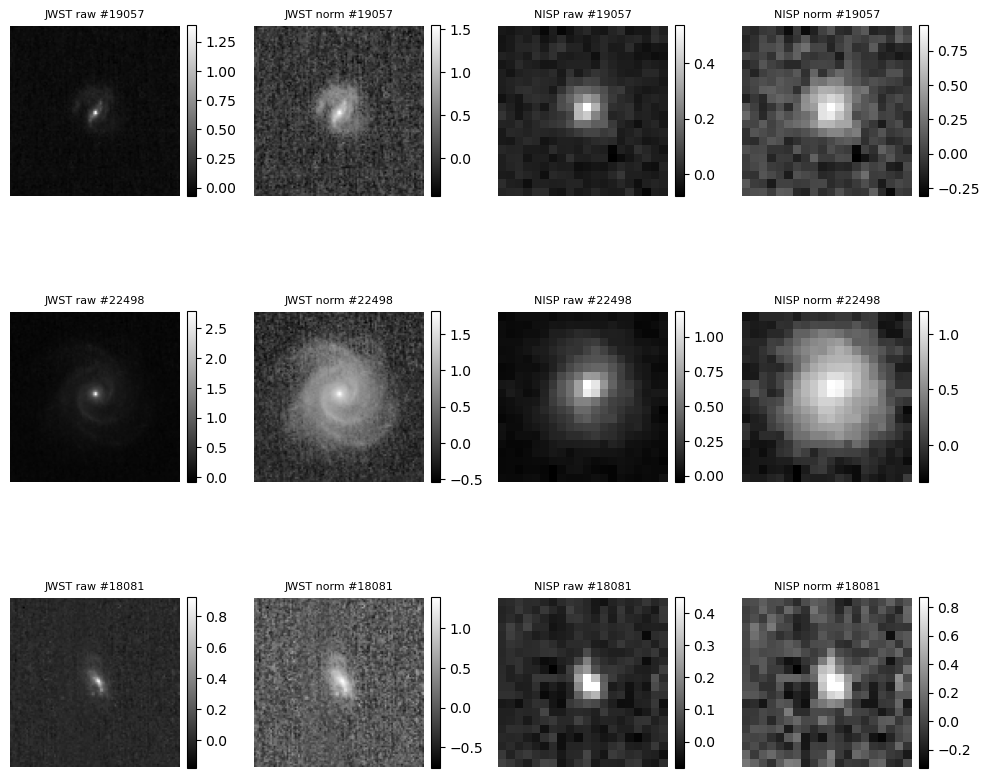

In [21]:
n_rows = 3                # a few examples
n_samples = n_rows        # one galaxy per row

np.random.seed(42)
random_indices = np.random.choice(len(jwst_cutouts), size=n_samples, replace=False)

nisp_crop_size = 21
jwst_crop_size = 105

fig, axes = plt.subplots(n_rows, 4, figsize=(10, 3*n_rows))

for row, i in enumerate(random_indices):
    clip_jwst = jwst_cutouts[i]
    clip_nisp = nisp_cutouts[i]

    # Center crops (same as before)
    jwst_h, jwst_w = clip_jwst.shape
    nisp_h, nisp_w = clip_nisp.shape

    jwst_crop = clip_jwst[jwst_h//2 - jwst_crop_size//2:jwst_h//2 + jwst_crop_size//2,
                          jwst_w//2 - jwst_crop_size//2:jwst_w//2 + jwst_crop_size//2]
    nisp_crop = clip_nisp[nisp_h//2 - nisp_crop_size//2:nisp_h//2 + nisp_crop_size//2,
                          nisp_w//2 - nisp_crop_size//2:nisp_w//2 + nisp_crop_size//2]

    # Normalized versions (we don't keep the backgrounds here, just for plotting)
    jwst_norm, _ = normalize_cutout(jwst_crop, jwst_params)
    nisp_norm, _ = normalize_cutout(nisp_crop, nisp_params)

    # Row layout: [0]=JWST raw, [1]=JWST norm, [2]=NISP raw, [3]=NISP norm
    ax0 = axes[row, 0]
    im0 = ax0.imshow(jwst_crop, origin='lower', cmap='gray')
    ax0.set_title(f'JWST raw #{i}', fontsize=8)
    ax0.axis('off')
    plt.colorbar(im0, ax=ax0, fraction=0.046, pad=0.04)

    ax1 = axes[row, 1]
    im1 = ax1.imshow(jwst_norm, origin='lower', cmap='gray')
    ax1.set_title(f'JWST norm #{i}', fontsize=8)
    ax1.axis('off')
    plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

    ax2 = axes[row, 2]
    im2 = ax2.imshow(nisp_crop, origin='lower', cmap='gray')
    ax2.set_title(f'NISP raw #{i}', fontsize=8)
    ax2.axis('off')
    plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

    ax3 = axes[row, 3]
    im3 = ax3.imshow(nisp_norm, origin='lower', cmap='gray')
    ax3.set_title(f'NISP norm #{i}', fontsize=8)
    ax3.axis('off')
    plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# Processing Euclid PSF file

In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os
import sys
from io import BytesIO
from astropy.io import fits
import matplotlib.pyplot as plt
import dropbox
import time
import glob
import warnings
import numpy as np
import scipy
import pandas as pd
from importlib import reload
# 
from astropy.wcs import WCS
from astropy.nddata import NDData
from astropy.wcs.utils import proj_plane_pixel_scales
from astropy.coordinates import SkyCoord
from astropy.nddata import Cutout2D
from astropy.table import Table
from astropy.wcs import FITSFixedWarning
from astropy import units as u
from scipy import ndimage
from photutils.psf import GriddedPSFModel
from reproject import reproject_interp
from skimage import restoration
from photutils import resize_psf

sys.path.insert(0, '/home/eaev/mer_psf/')
from mer.psf.MerCatalogPsf import MerCatalogPsf as mpsf
import clipping

In [ ]:
# Instantiate dropbox token
with open('../../secrets/dropbox_token') as token_file:
    token = token_file.read()
    dbx = dropbox.Dropbox(token.strip(), timeout=None)

cat = pd.read_csv("../catalog/matched_cat_cosmos_2.csv")
idx = 1029

jwst_file = cat.iloc[idx].jwst_image
psf_file = '../data/PSF_NIRCam_in_flight_opd_filter_F115W.fits'

hdr, jwst_data = clipping.get_fits_file(clipping.dbx_url, jwst_file, dbx, hdu_idx=0)
with fits.open(psf_file) as hdul:
    psf_hdr, psf_data = hdul[1].header, hdul[1].data

wcs = WCS(hdr)
sc = SkyCoord(cat.iloc[idx].ra, cat.iloc[idx].dec, unit='deg')

clip = Cutout2D(jwst_data, sc, 205, wcs=wcs)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(clip.data[60:-60,60:-60])

# zoomed = resize_psf(psf_data, 1, 6)
# zoomed /= np.sum(zoomed)

cx, cy = np.array(psf_data.shape)//2
zoomed = Cutout2D(psf_data, (cx, cy), 20)
axes[1].imshow(zoomed.data)

deconv, _ = restoration.unsupervised_wiener(clip.data[60:-60,60:-60], zoomed.data, clip=False)
axes[2].imshow(deconv)

In [ ]:
# Instantiate dropbox token
with open('../../secrets/dropbox_token') as token_file:
    token = token_file.read()
    dbx = dropbox.Dropbox(token.strip(), timeout=None)

cat = pd.read_csv("../catalog/matched_cat_cosmos_2.csv")
idx = 1029

nir_file = cat.iloc[idx].nisp_image
psf_file = cat.iloc[idx].psf_image

hdr, nir_data = clipping.get_fits_file(clipping.dbx_url, nir_file, dbx, hdu_idx=1)
_, psf_data = clipping.get_fits_file(clipping.dbx_url, psf_file, dbx, hdu_idx=1)
# mask_hdr, mask_data = clipping.get_fits_file(clipping.dbx_url, file, dbx, hdu_idx=2)
wcs = WCS(hdr)
# mask_wcs = WCS(mask_hdr)

sc = SkyCoord(cat.iloc[idx].ra, cat.iloc[idx].dec, unit='deg')

clip = Cutout2D(nir_data, sc, 41, wcs=wcs)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(clip.data)

zoomed = resize_psf(psf_data, 1, 6)
zoomed /= np.sum(zoomed)

axes[1].imshow(zoomed)

deconv, _ = restoration.unsupervised_wiener(clip.data, zoomed, clip=False)
axes[2].imshow(deconv)

In [ ]:
idx=17
ra, dec = cat.iloc[idx].ra, cat.iloc[idx].dec
sc = SkyCoord(ra, dec, unit="degree")

clip = Cutout2D(data, sc, size=41, wcs=wcs, mode='trim')
mask = Cutout2D(mask_data, sc, size=41, wcs=mask_wcs, mode='trim')
mask = (mask.data>=1)

# zoom_factor=4.37
# new_mask = ndimage.zoom(mask, zoom_factor, order=0, grid_mode=True)
plt.imshow(clip.data)
plt.show()
plt.imshow(mask)
plt.colorbar()
# plt.imshow(mask[35:38,30:35])
# plt.show()
# plt.imshow(new_mask[int(35*zoom_factor):int(38*zoom_factor),int(30*zoom_factor):int(35*zoom_factor)])

In [ ]:
x = np.ma.array(clip.data, mask=mask)
x.filled(0)
plt.imshow(x)
plt.colorbar()

In [ ]:
# # Instantiate dropbox token
# with open('../../secrets/dropbox_token') as token_file:
#     token = token_file.read()
#     dbx = dropbox.Dropbox(token.strip(), timeout=None)
# nisp_files = get_shared_folder_metadata(dbx_url, path='/new/', dbx=dbx)
# nisp_files = [file.name for file in nisp_files if 'IMAGE' in file.name]
# nisp_files

In [ ]:
# nir_file = '../data/EUC_NIR_W-CAL-IMAGE_Y-3025-0_20241001T144757.480636Z.fits'
# with fits.open(nir_file) as hdul:
#     plt.imshow(hdul[7].data[1030:1070,1030:1070])

In [ ]:
# clips = process_all('HUDF', redo_clips=True, save_clips=False)

In [ ]:
fig, axes = plt.subplots(1, 3)

idx = 200
test_nisp = np.pad(clips[idx][2].data, (0,1), mode='symmetric')
test_psf = clips[idx][3]

axes[0].imshow(test_nisp)
axes[0].set_xlabel("Before deconv (41x41)")
axes[1].imshow(test_psf)
axes[1].set_xlabel("PSF image (33x33)")

# Deconvolve
deconv, _ = restoration.unsupervised_wiener(test_nisp, test_psf, clip=False)
axes[2].imshow(deconv)
axes[2].set_xlabel("After deconv (41x41)")
plt.savefig("../plots/test_deconvolution.png", bbox_inches='tight')

In [ ]:
# fname = '../data/NISP_PSF_HUDF_NIR_Y/euclid_hudf_nir_Y.sh'
# new_fname = fname.replace('nir_Y', 'nir_Y_psf_only')
# with open(fname, 'r') as file:
#     lines = file.readlines()
#     lines = [lines[0]]+[el for el in lines if ('PSF' in el)]
#     # lines = [lines[0]]+[el for el in lines if (('PSF' in el) and ('CATALOG' in el))]

# with open(new_fname, 'w') as file:
#     file.writelines(lines)

In [ ]:
nir_psf_file = "../data/NISP_PSF_HUDF_NIR_Y/EUC_NIR_W-CAL-PSF-I_Y-3025-0_20241001T144843.454706Z.fits"

In [ ]:
euclid_psf_file1 = "../data/NISP_PSF_HUDF_MER_Y/EUC_MER_CATALOG-PSF-NIR-Y_TILE102044185-B0A5EA_20241021T060047.722344Z_00.00.fits"
euclid_psf_file2 = "../data/EUC_MER_GRID-PSF-NIR-Y_TILE101541377-C9907F_20240805T181919.717517Z_00.00.fits"
euclid_psf_file3 = "../data/EUC_MER_GRID-PSF-NIR-Y_TILE102086074-9D515F_20250305T113121.621151Z_00.00.fits"

In [ ]:
with fits.open(euclid_psf_file1) as hdul:
    hdr = hdul[1].header
    data = hdul[1].data
plt.imshow(data[:100,:100])

In [ ]:
epsf2 = ep.EuclidPSF(euclid_psf_file2)
epsf3 = ep.EuclidPSF(euclid_psf_file3)

clip2 = epsf2.data[8581-60:8581+200,0:200].copy()
clip2[np.where(clip2==0)] = .01

clip3 = epsf3.data[5461-60:5461+200,0:200]
clip3[np.where(clip3==0)] = .01

plt.imshow(clip2)
plt.show()
plt.imshow(clip3)

In [ ]:
sc = epsf3.wcs.pixel_to_world(10000, 60000)
clip = epsf3.evaluate(sc)
plt.imshow(clip)

In [ ]:
epsf3.psf_meta

In [ ]:
epsf2.psf_meta

In [ ]:
# psf1 = mpsf.from_file(euclid_psf_file1)

In [ ]:
# psf_clip = psf1.get_closest_stamp_at_radec((52.978595, -27.723529))
# psf_clip.normalize()
# psf_data = psf_clip.get_data()
# plt.imshow(psf_data)
# plt.grid()

In [ ]:
# with fits.open(euclid_psf_file1) as hdul:
#     hdr = hdul[1].header
#     hdr0 = hdul[0].header
#     wcs = WCS(hdr)
#     data = hdul[1].data
#     x_shape, y_shape = data.shape
# psf_info = Table.read(euclid_psf_file1, hdu=2).to_pandas()

# print(wcs.pixel_to_world(17, 50))
# psf_info

# # psf_size = 120 # Size of PSF image
# # stamp_size = 33 # PSF stamp size in pixel units
# # oversamp = psf_size / stamp_size
# # n_psfs = int((x_shape / psf_size) * (y_shape / psf_size))
# # x_bounds = np.arange(0, x_shape, psf_size)
# # y_bounds = np.arange(0, y_shape, psf_size)

# # data_array = np.zeros((n_psfs, psf_size, psf_size), dtype=float)
# # grid_xypos = np.zeros((n_psfs, 2), dtype=int)

# psf_info['coord'] = wcs.pixel_to_world(psf_info.y-1, psf_info.x-1)

# # i = 0
# # for x in x_bounds:
# #     for y in y_bounds:
# #         data_array[i] = data[y:y+psf_size, x:x+psf_size]
# #         grid_xypos[i] = (x+psf_size/2,y+psf_size/2)
# #         i = i+1

# # meta = {
# #     'grid_xypos': grid_xypos,
# #     'oversampling': 4,
# # }
# # data_meta = NDData(data_array, meta=meta)
# # # After all that, the oversampling factor can't be a decimal
# # # It works if I just set the oversampling to 4, no thank you
# # # !@#@#@!@3 this
# # # Ok, the WCS is wrong on the PSF images, at least the catalog ones
# hdr

In [ ]:
# psf_info

In [ ]:
# zeros_high = data.copy()
# zeros_high[data==0] = .05
# center = np.array([50, 17])
# clip = Cutout2D(zeros_high, center-1, 33)
# plt.imshow(clip.data)
# plt.grid()

In [ ]:
# plt.imshow(zeros_high[0:120, 0:120])

In [ ]:
# import euclid_psf as ep

In [ ]:
# reload(ep)

In [ ]:
# epsf = ep.EuclidPSF(euclid_psf_file1)

In [ ]:
# nisp_cutouts = np.load(meta['HUDF']['matched_nisp'])

In [ ]:
nisp_test = np.pad(clips[200][2].data, (1, 0), mode='symmetric')
plt.imshow(nisp_test)
psf_test = clips[200][3]

In [ ]:
# psf_pt = epsf.evaluate(psf_info.coord[50])
# zoomed = scipy.ndimage.zoom(psf_pt, , order=3)
# # plt.imshow(zoomed)
# zoomed = np.pad(zoomed, 4, mode='symmetric')
# plt.imshow(zoomed)

In [ ]:
freq_img = np.fft.fft2(padded)
freq_img = np.fft.fftshift(freq_img)
freq_psf = np.fft.fft2(zoomed)
freq_psf = np.fft.fftshift(freq_psf)

maybe_deconv = np.fft.ifftshift(freq_img / freq_psf)
maybe_deconv = np.fft.ifftshift(np.fft.ifft2(maybe_deconv))
plt.imshow(maybe_deconv.real)

In [ ]:
deconv, _ = restoration.unsupervised_wiener(nisp_test, psf_test, clip=False)
# fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plt.imshow(deconv)
# axes[1].imshow(padded)

In [ ]:
deconv = restoration.richardson_lucy(padded, zoomed, num_iter=30, clip=False)
plt.imshow(deconv)

In [ ]:
coords = wcs.pixel_to_world(psf_info.y-1, psf_info.x-1)
psf_info.coord[0].separation(coords).degree

In [ ]:
GriddedPSFModel(data_meta)

In [ ]:
with fits.open(euclid_psf_file2) as hdul:
    wcs = WCS(hdul[1].header)
    hdr = hdul[1].header

In [ ]:
psf_info = Table.read(euclid_psf_file1, hdu=2).to_pandas()
xgrid = np.sort(np.unique(psf_info.x))

In [ ]:
psf_info